# Weak Supervision


## Introduction

In this section, we apply what we learned in this chapter to implement **weak supervision**.
The idea behind weak supervision is that for each data point there is a latent true label that is inaccessible to us (even during training), instead we utilize weak signals from user-defined **labeling functions** (LF). The material here is an exposition and implementation of the **data programming** approach to weak supervision using LFs described in [@data-programming].

LFs can be thought of as heuristic rules that can be applied to a large subset of the data. In case the LF is not applicable, then the function simply abstains from making a prediction. Note that this is a realistic scenario, it's easier to describe rules than to manually annotate a large number of data. LFs provides noisy, less expensive labels, which can be useful in training noise-aware discriminative models. 

![**Weak supervision training pipeline**. The third image is flipped (i.e. the flow of prediction is right to left.) 
These two tasks will be implemented in this notebook. [Source](https://cs.brown.edu/people/sbach/files/bach-icml17-slides.pdf)](./img/01-weak-supervision-pipeline.png)

### Labeling Functions (LF)

Suppose we have a large corpus of IMDB movie reviews that we want to classify as positive or negative. Manually labeling thousands of reviews is expensive, but we can write heuristic rules called **labeling functions** (LF) that capture common patterns. Each LF inspects a review and returns `+1` (positive), `-1` (negative), or `0` (abstain).

In [1]:
#| output: false
import re
import numpy as np
import torch
import pandas as pd
from datasets import load_dataset

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)

ds = load_dataset("imdb")
train_ds = ds["train"].shuffle(seed=RANDOM_SEED).select(range(3000))
train_texts = train_ds["text"]
y_train_imdb = np.array(train_ds["label"])  # {0, 1}

K = 2
ABSTAIN = -1

Sample IMDB movie review (text) from the dataset:

In [2]:
print(y_train_imdb[0])
print("\n".join([train_texts[0][a: a + 80] for a in range(0, len(train_texts[0]), 80)]))

1
We always watch American movies with their particular accents from each region (
south, west, etc). We have the same here. All foreign people must to watch this 
movie and need to have a open mind to accept another culture, besides American a
nd European almost dominate the cinematographic industry.<br /><br />This movie 
tell us about a parallel world which it isn't figured even for those who live in
 a big city like São Paulo. All actors are improvising and they are very realist
ic. The camera give us an idea of their confuse world, the loneliness of each ch
aracter and invite us to share their world.<br /><br />It's a real great movie a
nd worst a rent even have it at home.


LFs can exploit many kinds of signals — word counts, explicit ratings, viewing behavior, or comparative language:

In [3]:
def lf_sentiment_words(text):
    text = text.lower()
    pos_count = sum(1 for w in ["great", "love", "amazing", "fun"] if w in text)
    neg_count = sum(1 for w in ["bad", "waste", "boring", "stupid"] if w in text)
    if pos_count > neg_count: return 1
    if neg_count > pos_count: return 0
    return ABSTAIN

def lf_viewing_experience(text):
    text_lower = text.lower()
    pos_watch = ["watched twice", "watch again", "rewatch", "couldn't stop watching"]
    neg_watch = ["walked out", "turned it off", "fell asleep", "couldn't finish"]
    pos = any(p in text_lower for p in pos_watch)
    neg = any(n in text_lower for n in neg_watch)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN

def lf_comparative_sentiment(text):
    text_lower = text.lower()
    if "worse than" in text_lower or "not as good as" in text_lower:
        return 0
    return ABSTAIN

Consider these example reviews and notice how each LF can be fooled or simply silent:

In [4]:
review = "I've watched this twice already and couldn't stop watching — the pacing is superb."

print("lf_sentiment_words      ", lf_sentiment_words(review))    # abstain (2) — no lexicon words match
print("lf_viewing_experience   ", lf_viewing_experience(review)) # positive (1) — "couldn't stop watching" signals engagement

lf_sentiment_words       -1
lf_viewing_experience    1


In [5]:
review = "An excellent way to waste your Friday night — worse than anything I've seen this year."

print("lf_sentiment_words      ", lf_sentiment_words(review))    # negative (0) — "waste" fires
print("lf_comparative_sentiment", lf_comparative_sentiment(review)) # negative (0) — "worse than"

lf_sentiment_words       0
lf_comparative_sentiment 0


In [6]:
review = """
This movie is an absolute DISASTER. Two hours of my life I'll never get back.
The plot makes zero sense, the acting is wooden, and the dialogue sounds like
it was written by a toddler. Every scene drags on forever. I've seen better
cinematography in a high school project. The sound mixing is atrocious — I
couldn't finish it. Zero stars.
"""

print("lf_sentiment_words      ", lf_sentiment_words(review))    # abstain (2) — no lexicon word dominates
print("lf_viewing_experience   ", lf_viewing_experience(review)) # negative (0) — "couldn't finish" fires
print("lf_comparative_sentiment", lf_comparative_sentiment(review)) # abstain (2) — no comparative phrase present

lf_sentiment_words       -1
lf_viewing_experience    0
lf_comparative_sentiment -1


### LF parameters

A labeling function is characterized by its **coverage** (fraction of inputs where it does not abstain) and **accuracy** (fraction correct among non-abstaining inputs). For the IMDB task, a full set of seven LFs has the following profile:

| LF | Coverage | Accuracy |
| :-: | :-: | :-: |
| `lf_strong_sentiment` | 0.41 | 0.88 |
| `lf_sentiment_words` | 0.69 | 0.76 |
| `lf_rating_mention` | 0.02 | 0.81 |
| `lf_viewing_experience` | 0.01 | 0.81 |
| `lf_comparative_sentiment` | 0.01 | 0.80 |
| `lf_recommendation` | 0.11 | 0.80 |
| `lf_exclamation_sentiment` | 0.05 | 0.81 |

[There is a natural trade-off:]{.underline} LFs with broad coverage (like `lf_sentiment_words`) tend to be less accurate, while highly accurate LFs fire on fewer reviews (`lf_strong_sentiment` is a massive exemption). The full definitions of these LFs and their application to IMDB data appear in the [application section](#application-imdb-movie-reviews) at the end of this notebook.

:::{.callout-note}
We generally do not have access to true labels for a representative sample of our dataset (or at best have access to a small labeled subset). Hence, even estimating the accuracy and coverage of our LFs is not possible. The following sections will deal with algorithms for estimating these parameters as well as training a machine learning model with noisy labels.
:::

:::{.callout-tip}
In practice, LFs are **iteratively refined**: we inspect disagreements between LFs, compare against any available ground truth, and consult domain knowledge. Since LFs are user-defined heuristics, they require some expertise and data exploration to be effective.
:::

## Basic theory


For simplicity, we will limit our presentation to binary classification, although the method extends to the multiclass setting. For each data point $\textbf{\textsf{x}} \in \mathcal{X},$ the latent true label is $y \in \mathcal{Y} = \{0, 1, \ldots, K-1\}$. Suppose we have $N$ **labeling functions** $\lambda_j\colon \mathcal{X} \to \mathcal{Y} \cup \{-1\},$ where $-1$ denotes **abstention**. Given $M$ data points $\textbf{\textsf{x}}_i,$ we obtain an $M \times N$ matrix of LF outputs $\Lambda_{ij} = \lambda_j(\textbf{\textsf{x}}_i)$.

We write $\Lambda$ for the random variable representing LF outputs and $\lambda(\textbf{\textsf{x}})$ for the realized output vector of a specific input. Our first step is to estimate the joint distribution $p_\Phi(\lambda, y)$ as well as the marginal $p_\Phi(\Lambda) = \prod_{i=1}^M p(\lambda(\textbf{\textsf{x}}_i)).$ We do MLE to find parameters $\hat{\Phi}$ that maximize the log-likelihood of the marginal 
$p_\Phi(\Lambda)$ of the observed LF outputs. See [below](/notebooks/tooling/10-weak-supervision.html#generative-model). This lets us calculate[^bayes]:

$$
\boxed{
    p_{\hat{\Phi}}(y \mid  \lambda(\textbf{\textsf{x}})) = \frac{p_{\hat{\Phi}}( y,\,  \lambda(\textbf{\textsf{x}}))}{p_{\hat{\Phi}}( \lambda(\textbf{\textsf{x}}))} = \frac{p_{\hat{\Phi}}( \lambda(\textbf{\textsf{x}}) \mid y)\, p_y}{\sum_{y'=0}^{K-1} p_{\hat{\Phi}}(\lambda(\textbf{\textsf{x}}) \mid y')\, p_{y'}}
}
$$ 

for any $y = 0, \ldots, K-1$ and any input $\textbf{\textsf{x}}.$ Given this, we perform **noise-aware training** (NAT) of a classifier $f_\Theta$ by minimizing the ff. loss:

$$
\boxed{
    \mathcal{L}_{\text{clf}}(\Theta) = 
    \frac{1}{M}\sum_{i=1}^M \sum_{y=0}^{K-1} 
    \ell(f_\Theta(\textbf{\textsf{x}}_i), y) \cdot 
    {p_{\hat{\Phi}}(y \mid  \lambda(\textbf{\textsf{x}}_i))}
}
$$

where $\ell$ is the usual loss criterion. This looks like the usual loss, except we don't have a single label. All labels contribute weighted by the probability of the label given the LF outputs of the input.

[^bayes]: While we need $p_{\hat{\Phi}}(y \mid  \lambda(\textbf{\textsf{x}}))$ for training, what we have access to is the reverse: $p_{\hat{\Phi}}(\lambda(\textbf{\textsf{x}}) \mid y)$ which we estimate by performing MLE on the LF outputs based on *all* targets (since we don't know which is the real one).

:::{.callout-note}
Each combination of $N$ LF outputs defines one of $3^N$ patterns, and the generative model assigns the same soft label to all points sharing a pattern. Exponential growth helps: 7 LFs yield $3^7 = 2{,}187$ bins. But no finite set can individuate every input. We rely on the data having enough low-dimensional structure that points in the same bin share a label distribution.
:::

### Generative model

Each LF has its own [confusion matrix](https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html) showing how its outputs relate to the true labels. For instance, `lf_sentiment_words` has asymmetric accuracy — it is much better at identifying positive reviews than negative ones:

In [7]:
from sklearn.metrics import confusion_matrix as cm

out = np.array([lf_sentiment_words(t) for t in train_texts])
F = out != ABSTAIN
label = y_train_imdb[F]
preds = out[F]

conf = cm(label, preds, labels=[0, 1])
df = pd.DataFrame(conf, index=["y=0 (neg)", "y=1 (pos)"], columns=["pred=0", "pred=1"])
df["abstain"] = [sum(y_train_imdb[~F] == 0).item(), sum(y_train_imdb[~F] == 1).item()]
df

,pred=0,pred=1,abstain
y=0 (neg),485,387,636
y=1 (pos),76,875,541


Observe that this can be converted to conditional probabilities given $y.$ Let's call the resulting matrix $\mathbf{C}^{(j)} \in [0, 1]^{K \times (K + 1)}$:

In [8]:
df / df.sum(axis=1).values.reshape(-1, 1)

,pred=0,pred=1,abstain
y=0 (neg),0.321618,0.256631,0.421751
y=1 (pos),0.050938,0.586461,0.362601


[This is precisely what the generative model will learn from input data.]{.mark} To see this, consider an input $\textbf{\textsf{x}}$, we get LF outputs $\lambda(\textbf{\textsf{x}}) \in [-1, 0, \ldots, K-1]^N.$ The conditional probability of this output vector given $y$ is then:

$$
\boxed{p(\lambda(\textbf{\textsf{x}}) ) = \sum_y  p_{y} \cdot p_{{\Phi}}(\lambda(\textbf{\textsf{x}}) \mid y) = \sum_{y} p_y \cdot \prod_j C^{(j)}_{y, \lambda_j}.}
$$

Here we have to provide the **prior distribution** since the labels are censored. Also, we assume that the LF outputs are conditionally independent given the true label. Note that the rows of $\mathbf{C}^{(j)}$ sum to 1, so in practice we let its entries range over $\mathbb{R}$ and just apply softmax later along the rows. Finally, our goal is to perform MLE on $\Phi = \{\mathbf{C}^{(1)}, \ldots, \mathbf{C}^{(N)}\}$ by minimizing over the dataset:

$$
\boxed{
    \mathcal{L}_{\text{gen}}(\Phi) = \sum_{i=1}^M -\log \left( 
        \sum_{y=0}^{K-1} p_y \cdot \prod_{j=1}^N C^{(j)}_{y,\, \Lambda_{ij}} 
    \right).
}
$$


:::{.callout-note}
**Why model $p(\Lambda \mid Y)$ rather than $p(Y \mid \Lambda)$ directly?** Because the forward direction &mdash; how each LF behaves given a true label &mdash; is what we can decompose per-LF and estimate from unlabeled data. Each LF has its own confusion matrix independent of the others. Bayes' rule then gives us the posterior we actually need.
:::

### Code implementation

We implement the confusion-matrix-based generative model. Each LF $j$ has a $K \times (K+1)$ confusion matrix $\mathbf{C}^{(j)}$. We stack these along the third dimension so that we get a tensor of shape $(K, K + 1, N).$ Since softmax is shift-invariant, we can initialize the abstain logits as $C_{y, K} = 0$ for all $y$, and derive its value from  non-abstain logits. This also makes it explicity that we have $K$ free parameters along a row.

In [9]:
import torch
torch.manual_seed(1)

K = 2  # number of classes
n = 4  # number of LFs

# Confusion matrix logits: shape (K, K, n) — non-abstain entries
# C_logits[y, k, j] is the unnormalized log-weight for P(λ_j = k | Y = y)
C_logits = torch.randn(K, K, n)

# Convert to probabilities via softmax-like normalization
# For each (y, :, j) we have K logits for classes 0...K-1
exp_logits = torch.exp(C_logits)                      # (K, K, n)
denom = 1.0 + exp_logits.sum(dim=1, keepdim=True)     # (K, 1, n)  exp(0) = 1 for abstain
p_classes = exp_logits / denom                        # (K, K, n)  P(λ=k | y) for k in {0,...,K-1}
p_abstain = 1.0 / denom                               # 1 for abstain entry

# Full confusion matrix: (K, K+1, n)
C = torch.cat([p_classes, p_abstain], dim=1)          # (K, K+1, n)

# Challenge: read off the LF accuracies from C
print("Confusion matrix shape:", C.shape)
print(C)
print(C.sum(dim=1).numpy().sum())   # ~8 (2 targets x 4 LFs)

Confusion matrix shape: torch.Size([2, 3, 4])
tensor([[[0.1025, 0.2342, 0.2743, 0.1428],
         [0.4263, 0.2697, 0.1981, 0.1429],
         [0.4712, 0.4960, 0.5276, 0.7143]],

        [[0.2141, 0.1746, 0.1692, 0.2305],
         [0.3495, 0.6965, 0.4626, 0.4731],
         [0.4364, 0.1289, 0.3682, 0.2964]]])
8.0


We index into the confusion matrix using the LF output matrix. Class labels $\{0, \ldots, K-1\}$ map to the first $K$ columns, and abstain ($K$) maps to the last column. No remapping needed:

In [10]:
# Example LF output matrix: values in {0, 1, ..., K} where K = abstain
L = torch.tensor([
    [0, K,  1,  1],
    [1, 0,  0,  K],
])

# P(L | y=1): for each instance i and LF j, look up C[y=1, L[i,j], j]
y = 1
C[y, L, torch.arange(n)]  # shape: (m, n)

tensor([[0.2141, 0.1289, 0.4626, 0.4731],
        [0.3495, 0.1746, 0.1692, 0.2964]])

The product across LFs gives the conditional likelihood of the observed LF outputs for a given true label:

In [11]:
# P(Λ_i | y) = prod_j C[y, Λ_{ij}, j]
for y in range(K):
    probs = C[y, L, torch.arange(n)]  # (m, n)
    print(f"P(Λ | y={y}):", probs.prod(dim=1))

P(Λ | y=0): tensor([0.0014, 0.0196])
P(Λ | y=1): tensor([0.0060, 0.0031])


The marginal probability of the two LF outputs over the latent label:

In [12]:
py = torch.tensor([0.5, 0.5])  # class prior

p_marginal = sum(
    py[y] * C[y, L, torch.arange(n)].prod(dim=1)
    for y in range(K)
)

print("P([Λ0, Λ1]):", p_marginal)

P([Λ0, Λ1]): tensor([0.0037, 0.0113])


Finally, the marginal probability of the sample $p_{\Phi}(\Lambda).$ Because we generally have $M \gg 1$ terms with values in $[0, 1]$, we use $\log$ to avoid underflow:

In [13]:
print("     p(Λ):", p_marginal.prod().item())
print("-log p(Λ):", -torch.log(p_marginal).sum().item())

     p(Λ): 4.230787817505188e-05
-log p(Λ): 10.070537567138672


## Experiments

We collect the above snippets into a class:

In [14]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
import random
import numpy as np
import pandas as pd

from notebooks.plot import set_format
set_format("svg")

RANDOM_SEED = 0
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = (
    torch.device("cuda:0") if torch.cuda.is_available() else (
        torch.device("mps") if torch.mps.is_available() else 
            torch.device("cpu")
    )
)

print(f"Using device: {DEVICE}")

Using device: mps


### Simulated LFs

Generating a toy dataset. Also setting the prior label probabilities:

In [15]:
m = 10000
K = 2
LABEL_PROBS = {0: 0.40, 1: 0.60}
y_true = np.random.choice([0, 1], size=m, p=[LABEL_PROBS[0], LABEL_PROBS[1]])

s = 2 * torch.pi * torch.rand(m, 1)
r = 0.5 * torch.tensor(y_true, dtype=torch.float32).view(-1, 1)  # 0 -> r=0, 1 -> r=0.5
x = torch.cat([r * torch.cos(s), r * torch.sin(s)], dim=1) + 0.05 * torch.randn(m, 2)

t = np.linspace(0, 2*np.pi, 100)
x0 = 0.5 * np.cos(t)
x1 = 0.5 * np.sin(t)
x_neg = x[torch.where(torch.tensor(y_true) == 0)]
x_pos = x[torch.where(torch.tensor(y_true) == 1)]

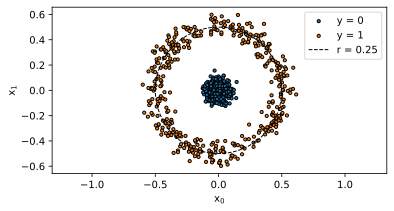

In [16]:
#| code-fold: true
def plot_dataset(x_neg, x_pos):
    m = len(x_neg)
    limit = m // 10
    plt.figure(figsize=(6, 3))
    plt.scatter(x_neg[:limit, 0], x_neg[:limit, 1], s=10.0, edgecolor="k", color="C0", label="y = 0")
    plt.scatter(x_pos[:limit, 0], x_pos[:limit, 1], s=10.0, edgecolor="k", color="C1", label="y = 1")
    plt.plot(x0, x1, color='black', linewidth=1, linestyle='dashed', label="r = 0.25")
    plt.xlabel("x$_0$")
    plt.ylabel("x$_1$")
    plt.legend()
    plt.axis("equal")

plot_dataset(x_neg, x_pos)

**Figure.** Below we use $r = 0.25$ as basis for synthetic LFs.

Note that radius less than 0.25 determines the label as $y = 0$ (with high probability):

In [17]:
# radius >= 0.25 -> class 1, else class 0
((torch.sqrt((x ** 2).sum(dim=1)) >= 0.25).long().numpy() == y_true).mean()

np.float64(1.0)

We use this to write simulated LFs with given parameters:

In [18]:
def lf_sim(coverage, accuracy):
    def predict(x):
        m = x.shape[0]
        y = (torch.sqrt((x ** 2).sum(dim=1)) >= 0.25).long()  # 0 or 1
        abstain_mask = torch.rand(m) >= coverage
        flip_mask = torch.rand(m) >= accuracy
        y[flip_mask] = 1 - y[flip_mask]    # flip label
        y[abstain_mask] = -1               # abstain
        return y
    return predict

# example
p = lf_sim(0.3, 0.8)(x).numpy()
fired = p != K
print("cov: ", fired.mean())
print("acc: ", (p[fired] == y_true[fired]).mean())
print("acc (y=0):", (p[fired & (y_true == 0)] == y_true[fired & (y_true == 0)]).mean())
print("acc (y=1):", (p[fired & (y_true == 1)] == y_true[fired & (y_true == 1)]).mean())

cov:  1.0
acc:  0.2378
acc (y=0): 0.24224373293621246
acc (y=1): 0.2348015407804388


Initializing the empirical LF matrix for display. Some LFs have fairly low accuracy:

In [19]:
lf_params = [(0.30, 0.75), (0.50, 0.65), (0.40, 0.70), (0.20, 0.80), (0.25, 0.90)]
labeling_funcs = [lf_sim(*param) for param in lf_params]

df = pd.DataFrame({"y": y_true})
df["x0"] = x[:, 0].numpy()
df["x1"] = x[:, 1].numpy()
for j, lf in enumerate(labeling_funcs):
    df[f"LF{j + 1}"] = lf(x).int().numpy()

print(df.shape)
df.head()

(10000, 8)


,y,x0,x1,LF1,LF2,LF3,LF4,LF5
0,1,-0.599245,0.044822,-1,1,-1,-1,-1
1,1,0.045224,-0.489432,-1,-1,0,-1,-1
2,1,0.367845,0.195856,-1,1,0,1,-1
3,1,0.345199,0.440180,-1,-1,-1,-1,-1
4,1,-0.138734,0.433529,1,1,-1,-1,-1


**Data split and LF matrix.** We split the data 80-20 for evaluation and precompute the LF output matrix $\Lambda$ for each split. Since `lf_sim` is stochastic (each call generates a fresh random sample), we call each LF once per split and store the results:

In [20]:
# 80-20
SPLIT_RATIO = 0.80
m = x.shape[0]
x_train = x[:int(SPLIT_RATIO * m)]
x_valid = x[int(SPLIT_RATIO * m):]
y_train = torch.tensor(y_true[:int(SPLIT_RATIO * m)])
y_valid = torch.tensor(y_true[int(SPLIT_RATIO * m):])


def build_L(labeling_funcs, x):
    """Build LF output matrix from labeling functions. Shape: (m, N)."""
    return torch.stack([lf(x) for lf in labeling_funcs], dim=1).long()


L_train = build_L(labeling_funcs, x_train)
L_valid = build_L(labeling_funcs, x_valid)
print(f"L_train: {L_train.shape}, L_valid: {L_valid.shape}")

L_train: torch.Size([8000, 5]), L_valid: torch.Size([2000, 5])


### Generative model training

:::{.callout-note}
We train the generative model with **Adam** (@adam) and full-batch gradient descent. The logits are [**warm-started** with a diagonal preference]{.mark} (`logits[y, y, :] += 1.0`) ( ˶°ㅁ°) !! to encourage the model to assign higher probability to the correct class initially. This bias resulted in significantly better performance.
:::

In [21]:
class GenModel:
    def __init__(self, num_classes: int, class_prior: list = None):
        class_prior = [1.0 / num_classes] * num_classes if class_prior is None else class_prior
        self.K = num_classes
        self.py = torch.tensor(class_prior, dtype=torch.float32)  # shape (K,)
        self.C = None  # confusion matrices: (K, K+1, n)

    def _build_C(self, logits):
        """Convert logits (K, K, n) to confusion matrices (K, K+1, n).
        Columns: [class 0, ..., class K-1, abstain]."""
        exp_l = torch.exp(logits)                              # (K, K, n)
        denom = 1 + exp_l.sum(dim=1, keepdim=True)             # (K, 1, n)
        p_classes = exp_l / denom                              # (K, K, n)
        p_abstain = 1.0 / denom                                # (K, 1, n)
        return torch.cat([p_classes, p_abstain], dim=1)        # (K, K+1, n)

    def loss_fn(self, L):
        p = sum(
            self.py[y] * self.C[y, L, torch.arange(L.shape[1])].prod(dim=1)
            for y in range(self.K)
        )
        return -torch.log(p + 1e-12).mean()

    def fit(self, L_train, L_valid=None, epochs=1, lr=0.01):
        """MLE estimate of confusion matrix parameters."""
        m, n = L_train.shape

        logits = 0.1 * torch.randn(self.K, self.K, n)  # <1>
        for y in range(self.K):
            logits[y, y, :] += 1.0
        logits = torch.nn.Parameter(logits)
        optimizer = torch.optim.Adam([logits], lr=lr)  # <2>

        history = {"train": [], "valid": [], "valid_steps": []}
        checkpoint = (None, np.inf)

        try:
            for e in tqdm(range(epochs)):
                self.C = self._build_C(logits)
                loss = self.loss_fn(L_train)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                history["train"].append(loss.item())

                with torch.no_grad():
                    if L_valid is not None:
                        self.C = self._build_C(logits)
                        val_loss = self.loss_fn(L_valid)
                        history["valid"].append(val_loss.item())
                        history["valid_steps"].append(e + 1)
                        if val_loss.item() < checkpoint[1]:
                            checkpoint = (self._build_C(logits).detach().clone(), val_loss.item())

        except KeyboardInterrupt:
            print("Training stopped.")

        finally:
            self.C = checkpoint[0]
            return history

    def predict(self, L, t=None):
        """Label inference via argmax p(y | Λ).
        For binary case, threshold t on p(y=1) can be used instead."""
        if t is not None and self.K == 2:
            p = self.target_cond_proba(1, L)
            return (p >= t).long()
        probs = torch.stack([self.target_cond_proba(y, L) for y in range(self.K)], dim=1)
        return probs.argmax(dim=1)

    def target_cond_proba(self, y, L):
        """Estimate p(Y=y | Λ) via Bayes' rule."""
        joint = [self.infer_joint_proba(L, k) for k in range(self.K)]
        p_tot = sum(joint)
        return joint[y] / (p_tot + 1e-12)

    def infer_joint_proba(self, L, y: int):
        """Return p(Λ_i, Y=y) for each instance. Shape: (m,)."""
        n = L.shape[1]
        return self.py[y] * self.C[y, L, torch.arange(n)].prod(dim=1)


gen_model = GenModel(num_classes=K, class_prior=[LABEL_PROBS[0], LABEL_PROBS[1]])
history = gen_model.fit(L_train, L_valid, epochs=5000, lr=0.01)

100%|██████████| 5000/5000 [00:31<00:00, 158.44it/s]


1. Logits are initialized to have $0.1$ variance, with diagonal entries shifted by $+1$.
2. Adam on [full batch]{.underline} with the LF confusion parameters. Since the model is simple there is no benefit to adding noise with SGD, and we simply try to overfit on the LF outputs. The curve below validates this hypothesis.

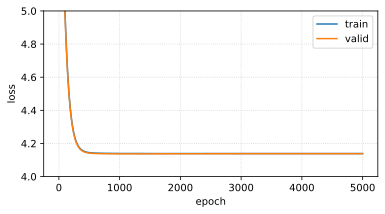

In [22]:
#| code-fold: true
plt.figure(figsize=(6, 3))
plt.plot(history["train"], label="train")
plt.plot(history["valid_steps"], history["valid"], label="valid")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.ylim(4, 5)
plt.legend()
plt.grid(linestyle="dotted", alpha=0.6)

The model recovers the latent LF parameters better when coverage is high. Low-coverage LFs have fewer observed (non-abstain) outputs, making their confusion matrices harder to estimate:

In [23]:
rows = []
for j in range(len(lf_params)):
    C_j = gen_model.C[:, :, j]
    K = C_j.shape[0]
    est_acc = C_j.diagonal().sum().item() / C_j[:K, :K].sum().item()
    est_cov = 1.0 - C_j[:, -1].sum().item() / C_j.sum().item()
    rows.append({
        "lf": f"LF{j+1}",
        "latent cov": lf_params[j][0],
        "est cov":    round(est_cov, 2),
        "latent acc": lf_params[j][1],
        "est acc":    round(est_acc, 2),
    })
    
pd.DataFrame(rows).set_index("lf")

,latent cov,est cov,latent acc,est acc
lf,,,,
LF1,0.30,0.30,0.75,0.78
LF2,0.50,0.50,0.65,0.64
LF3,0.40,0.40,0.70,0.71
LF4,0.20,0.20,0.80,0.77
LF5,0.25,0.25,0.90,0.85


In [24]:
#| code-fold: true
frames = []
for j in range(len(lf_params)):
    C_j = gen_model.C[:, :, j]
    df = pd.DataFrame(
        C_j.numpy(),
        index=pd.MultiIndex.from_tuples([(f"LF{j+1}", f"y={k}") for k in range(K)]),
        columns=[f"pred={k}" for k in range(K)] + ["abstain"]
    )
    frames.append(df)
pd.concat(frames)

pred=0    pred=1   abstain
LF1 y=0  0.236651  0.066162  0.697187
    y=1  0.066899  0.224532  0.708569
LF2 y=0  0.325942  0.190593  0.483465
    y=1  0.166348  0.307258  0.526394
LF3 y=0  0.286706  0.117108  0.596186
    y=1  0.117727  0.275034  0.607239
LF4 y=0  0.162283  0.049308  0.788410
    y=1  0.043841  0.152895  0.803264
LF5 y=0  0.201536  0.039801  0.758663
    y=1  0.034914  0.225579  0.739506

The trained model can be used to estimate joint probabilities of LF outputs and targets:

In [25]:
# Simple test that the model learned (without using latent labels):
l = torch.tensor([[1, 1, 1, 1, 1]])
for y in range(K):
    print(f"p(y={y} | Λ=all_pos): {gen_model.target_cond_proba(y, l).item():.4f}")

# Simple test that the model learned (without using latent labels):
print()
l = torch.tensor([[0, 0, 0, 0, 0]])
for y in range(K):
    print(f"p(y={y} | Λ=all_neg): {gen_model.target_cond_proba(y, l).item():.4f}")

p(y=0 | Λ=all_pos): 0.0029
p(y=1 | Λ=all_pos): 0.9971

p(y=0 | Λ=all_neg): 0.9959
p(y=1 | Λ=all_neg): 0.0041


> Also note that the conditional probabilities of targets given LF outputs sum to 1. (sanity)

In [26]:
l = torch.tensor([[-1, -1, -1, -1, -1]])
for y in range(K):
    print(f"p(y={y} | Λ=all_neg): {gen_model.target_cond_proba(y, l).item():.4f}")

p(y=0 | Λ=all_neg): 0.3733
p(y=1 | Λ=all_neg): 0.6267


:::{.callout-note}
If all LFs abstain, the posterior reduces to the **class prior**. When $\lambda_j(\textbf{\textsf{x}}) = K$ for all $j$, the marginal becomes $p_y \cdot \prod_j C^{(j)}_{y,K}$. Because we initialize abstain logits to zero, the common factor cancels in Bayes' rule and only $p_y$ remains — and remain so since they receive little gradient signal. This holds approximately in practice due to sparse gradient signal on the abstain columns during training.
:::

### Label inference

Soft labels can be generated for a test input using $p_{\hat{\Phi}}(y \mid \lambda(\textbf{\textsf{x}}))$ calculated using learned LF parameters. This already takes into account the prior label distribution. In particular, if all LFs abstain, then the model falls back to the prior label distribution. Evaluating using latent labels:

In [27]:
from sklearn.metrics import (
    f1_score, 
    confusion_matrix, 
    precision_score, 
    recall_score
)

import warnings
warnings.filterwarnings("ignore")


def evaluate(model, x, y, t=None, verbose=True):
    m = x.shape[0]
    preds = model.predict(x, t)
    f1 = f1_score(y.numpy(), preds.numpy(), average="weighted")
    recall = recall_score(y.numpy(), preds.numpy(), average="weighted")
    precision = precision_score(y.numpy(), preds.numpy(), average="weighted")
    
    if verbose:
        print(confusion_matrix(y.numpy(), preds.numpy()))
    
    t_str = f", t={t:.5f}" if t is not None else ""
    return {
        "f1": f1,
        "recall": recall,
        "precision": precision,
        "m": m, "message": f"m={m}, f1={f1:.5f}{t_str}"
    }

print(evaluate(gen_model, L_train, y_train)["message"]); print()
print(evaluate(gen_model, L_valid, y_valid)["message"])

[[2034 1209]
 [ 699 4058]]
m=8000, f1=0.75739

[[ 515  271]
 [ 168 1046]]
m=2000, f1=0.77727


### Noise-aware training

Noise-aware training amounts to weighting the loss with the estimate of the generative model for each target ${p_{\hat{\Phi}}(y \mid \lambda(\textbf{\textsf{x}}))} = {p_{\hat{\Phi}}(y,\, \lambda(\textbf{\textsf{x}}))}
\, /\, {p_{\hat{\Phi}}(\lambda(\textbf{\textsf{x}}))}.$ This allows us to train a model without labels:

In [28]:
import torch.nn as nn
from tempfile import NamedTemporaryFile
np.random.seed(42); torch.manual_seed(42)


class NoiseAwareTrainer:
    def __init__(self, clf, gen_model):
        self.clf = clf
        self.K = gen_model.K
        self.gen_model = gen_model

    def loss_fn(self, L, x):
        with torch.no_grad():
            # p(y | Λ) for each class — shape (m, K)
            cond_probs = torch.stack(
                [self.gen_model.target_cond_proba(y, L) for y in range(self.K)], dim=1
            )
        logits = self.clf(x)                                       # (m, K)
        log_probs = torch.log_softmax(logits, dim=1)               # (m, K)
        return -(cond_probs * log_probs).sum(dim=1).mean()

    def run(self, x_train, x_valid, L_train, L_valid=None, epochs=10, bs=8, lr=0.001, alpha=0.0, momentum=0.1):
        m = x_train.shape[0]
        history = {"train": [], "valid": [], "valid_steps": []}
        best_loss = np.inf
        best_epoch = 0
        optim = torch.optim.SGD(self.clf.parameters(), lr=lr, weight_decay=alpha, momentum=momentum)
        tmp = NamedTemporaryFile(suffix=".pt", delete=True)

        try: 
            for epoch in tqdm(range(epochs)):
                B = torch.randperm(m)
                for i in range(m // bs):
                    batch = B[i * bs: (i + 1) * bs]
                    loss = self.loss_fn(L_train[batch], x_train[batch])

                    # gradient step
                    loss.backward()
                    optim.step()
                    optim.zero_grad()

                    # callbacks
                    history["train"].append(loss.item())
                            
                    del loss
                    torch.cuda.empty_cache()
                
                with torch.no_grad():
                    if x_valid is not None:
                        val_loss = self.loss_fn(L_valid, x_valid)
                        history["valid"].append(val_loss.item())
                        history["valid_steps"].append((epoch + 1) * (m // bs))
                        if val_loss < best_loss:
                            best_loss = val_loss.item()
                            best_epoch = epoch
                            torch.save(self.clf.state_dict(), tmp.name)

                if epoch - best_epoch > int(0.05 * epochs):
                    print(f"Early stopping at epoch {epoch}...")
                    raise KeyboardInterrupt

        except KeyboardInterrupt:
            print("Training stopped.")

        finally:
            print(f"Best valid loss: {best_loss}")
            self.clf.load_state_dict(torch.load(tmp.name, weights_only=True))
            return history

    @torch.no_grad()
    def predict_proba(self, x):
        """Return class probabilities. Shape: (m, K)."""
        logits = self.clf(x)                                       # (m, K)
        return torch.softmax(logits, dim=1)

    @torch.no_grad()
    def predict(self, x, t=None):
        """Predict labels. For binary, threshold t on p(y=1) can be used."""
        probs = self.predict_proba(x)
        if t is not None and self.K == 2:
            return (probs[:, 1] >= t).long()
        return probs.argmax(dim=1)


clf = nn.Sequential(nn.Linear(2, 8), nn.SELU(), nn.Linear(8, K))
trainer = NoiseAwareTrainer(clf, gen_model)
history = trainer.run(x_train, x_valid, L_train, L_valid, epochs=120, bs=32, lr=0.003, alpha=0.0, momentum=0.1)

100%|██████████| 120/120 [00:16<00:00,  7.33it/s]

Best valid loss: 0.6634567975997925


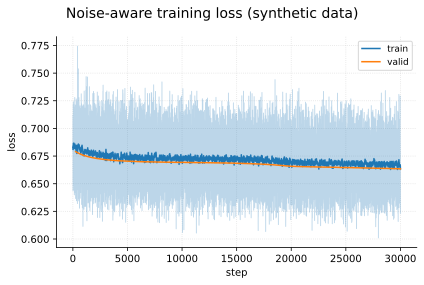

In [29]:
#| code-fold: true
from notebooks.plot import Plot

p = Plot(figsize=(6, 4), title="Noise-aware training loss (synthetic data)")
p[0].line(history["train"], color="C0", label="train", smooth=100)
p[0].line(history["valid"], x=history["valid_steps"], color="C1", label="valid")
p[0].labels(x="step", y="loss")
p.legend(loc="upper right", frameon=True)
p.show()

The model clearly trained by the default threshold is not calibrated:

In [30]:
print(evaluate(trainer, x_train, y_train, t=0.5)["message"]); print()
print(evaluate(trainer, x_valid, y_valid, t=0.5)["message"])

[[   0 3243]
 [   0 4757]]
m=8000, f1=0.44346, t=0.50000

[[   0  786]
 [   0 1214]]
m=2000, f1=0.45856, t=0.50000


There are two ways to improve the threshold `t` (both not free, i.e. requires some assumptions):

**1. Matching the label prior distribution.** The threshold for predicting hard labels can be calibrated by using the prior label distribution. This significantly improves F1. Here we use the entirety of our data (i.e. `x`):

In [31]:
from collections import Counter

calibration_score = []  # lower = better
thresholds = np.linspace(0, 1, num=500)
for t in thresholds:
    c = Counter(trainer.predict(x, t).tolist())
    n = len(x)
    c[0] = c.get(0, 1) / n 
    c[1] = c.get(1, 1) / n 
    calibration_score.append(-LABEL_PROBS[0] * np.log(c[0]) + -LABEL_PROBS[1] * np.log(c[1]))


t_best = thresholds[np.argmin(calibration_score)]
print(evaluate(trainer, x_train, y_train, t=t_best)["message"]); print()
print(evaluate(trainer, x_valid, y_valid, t=t_best)["message"])

[[2245  998]
 [ 870 3887]]
m=8000, f1=0.76570, t=0.59118

[[ 515  271]
 [ 193 1021]]
m=2000, f1=0.76555, t=0.59118


:::{.callout-note }
This calibration uses the **entire** dataset `x` (both train and valid) and assumes exact [knowledge of the class prior]{.mark} `LABEL_PROBS`. The cross-entropy objective selects the threshold $t$ whose predicted label distribution best matches the prior. If the prior estimate is inaccurate, the selected [decision threshold]{.underline} shifts accordingly: overestimating $p(y=1)$ pushes $t$ lower (more positive predictions), while underestimating it pushes $t$ higher. In practice, the class prior is rarely known exactly, so this approach is sensitive to estimation error &mdash; especially for imbalanced problems.
:::

**2. Tuning on a labeled subset.** If a representative subset of the data is labeled, even if small, then we can use that to tune the threshold. The following iteratively finds the threshold that maximizes weighted F1 on the validation set:

[[3136  107]
 [1097 3660]]
m=8000, f1=0.85073, t=0.59560

[[569  21]
 [203 707]]
m=1500, f1=0.85235, t=0.59560


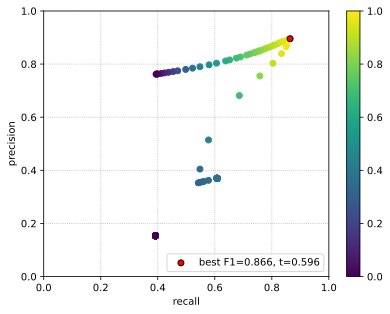

In [32]:
def pr_curve(model, x, y, num_thresholds, min_t=0.0, max_t=1.0):
    p, r, t, f = [], [], [], []
    for threshold in np.linspace(min_t, max_t, num_thresholds):
        preds = model.predict(x, threshold).numpy()
        f.append(f1_score(y.numpy(), preds, average="weighted"))
        r.append(recall_score(y.numpy(), preds, average="weighted"))
        p.append(precision_score(y.numpy(), preds, average="weighted"))
        t.append(threshold)
    
    return p, r, t, f

def plot_pr_curve(model, x, y, num_thresholds=200, min_t=0.0, max_t=1.0):
    """Tune threshold based on validation set."""
    p, r, t, f = pr_curve(model, x, y, num_thresholds, min_t, max_t);
    t_best_idx = np.argmax(f)
    t_best = t[t_best_idx]

    # plotting the sample F1s
    plt.grid(linestyle="dotted", zorder=0)
    plt.scatter(r, p, c=f, zorder=2)
    plt.scatter(x=r[t_best_idx], y=p[t_best_idx], edgecolor="k", facecolor="red", label=f"best F1={f[t_best_idx]:.3f}, t={t_best:.3f}", zorder=3)
    plt.colorbar()
    plt.xlabel("recall")
    plt.ylabel("precision")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend(loc="lower right")

    return t_best


# Tuning the threshold on a labeled subset (here 500 pts)
t_best = plot_pr_curve(trainer, x_valid[:500], y_valid[:500], num_thresholds=1000, min_t=0.0, max_t=1.0)
print(evaluate(trainer, x_train, y_train, t=t_best)["message"]); print()
print(evaluate(trainer, x_valid[500:], y_valid[500:], t=t_best)["message"])

:::{.callout-note}
With threshold calibration, the noise-aware model achieves F1 $\approx 0.85$ on both training data and the labeled validation split &mdash; a substantial improvement over the generative model's F1 $\approx 0.75.$ This demonstrates that the discriminative model learns decision boundaries beyond what the LFs alone can express.
:::

---

## Application: IMDB Movie Reviews

We apply the same weak supervision pipeline to a real text classification task: **IMDB movie review sentiment analysis**. The key challenge is adapting our `GenModel` and `NoiseAwareTrainer` (designed for tensor inputs) to work with raw text data. We define text-based labeling functions that detect sentiment patterns, wrap them to be tensor-compatible, and use TF-IDF features to train the noise-aware discriminative model.

In [33]:
#| output: false
import re
import pandas as pd
from datasets import load_dataset

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


# Load IMDB dataset (3000 train, 1000 valid)
ds = load_dataset("imdb")
train_ds = ds["train"].shuffle(seed=RANDOM_SEED).select(range(3000))
valid_ds = ds["test"].shuffle(seed=RANDOM_SEED).select(range(1000))

train_texts = train_ds["text"]
valid_texts = valid_ds["text"]
y_train_imdb = torch.tensor(train_ds["label"])    # {0, 1}
y_valid_imdb = torch.tensor(valid_ds["label"])

K = 2
ABSTAIN = K


# (1) Strong adjectives
def lf_strong_sentiment(text):
    text = text.lower()
    pos_words = ["excellent", "masterpiece", "outstanding", "brilliant", "perfect", "superb", "fantastic", "wonderful"]
    neg_words = ["terrible", "awful", "horrible", "worst", "dreadful", "atrocious", "abysmal", "pathetic"]
    pos = any(w in text for w in pos_words)
    neg = any(w in text for w in neg_words)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN


# (2) Balance of positive/negative word counts
def lf_sentiment_words(text):
    text = text.lower()
    pos_words = ["great", "love", "amazing", "best", "enjoyed", "favorite", "fun"]
    neg_words = ["bad", "waste", "boring", "poor", "stupid", "annoying", "disappointing"]
    pos_count = sum(1 for w in pos_words if w in text)
    neg_count = sum(1 for w in neg_words if w in text)
    if pos_count > neg_count: return 1
    if neg_count > pos_count: return 0
    return ABSTAIN


# (3) Explicit ratings (e.g. "10/10", "1 star")
def lf_rating_mention(text):
    text = text.lower()
    pos_patterns = [r"10/10", r"10 out of 10", r"5 stars", r"5/5"]
    neg_patterns = [r"1/10", r"1 out of 10", r"1 star[^s]", r"0 stars", r"0/10"]
    pos = any(re.search(p, text) for p in pos_patterns)
    neg = any(re.search(p, text) for p in neg_patterns)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN


# (4) Re-watch / walk-out behavior
def lf_viewing_experience(text):
    text_lower = text.lower()
    pos_watch = ["watched twice", "seen it multiple times", "watch again", "rewatch", "couldn't stop watching"]
    neg_watch = ["walked out", "turned it off", "fell asleep", "couldn't finish", "wasted 2 hours"]
    pos = any(p in text_lower for p in pos_watch)
    neg = any(n in text_lower for n in neg_watch)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN


# (5) Negative comparative phrases
def lf_comparative_sentiment(text):
    text_lower = text.lower()
    if "worse than" in text_lower or "not as good as" in text_lower or "disappointing compared" in text_lower:
        return 0
    return ABSTAIN


# (6) Recommendation / avoidance phrases
def lf_recommendation(text):
    text = text.lower()
    pos_phrases = ["highly recommend", "must see", "must watch", "worth watching", "go see", "definitely watch", "check it out"]
    neg_phrases = ["do not recommend", "don't recommend", "avoid", "skip this", "don't bother", "don't waste", "stay away", "save your"]
    pos = any(p in text for p in pos_phrases)
    neg = any(p in text for p in neg_phrases)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN


# (7) Exclamation + sentiment phrases
def lf_exclamation_sentiment(text):
    if "!" not in text: return ABSTAIN
    text = text.lower()
    pos_phrases = ["loved it", "great film", "great movie", "must see", "highly recommended", "well done"]
    neg_phrases = ["waste of time", "don't watch", "stay away", "save your money", "never again", "so bad"]
    pos = any(p in text for p in pos_phrases)
    neg = any(p in text for p in neg_phrases)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN


text_lfs_raw = [
    lf_strong_sentiment,
    lf_sentiment_words,
    lf_rating_mention,
    lf_viewing_experience,
    lf_comparative_sentiment,
    lf_recommendation,
    lf_exclamation_sentiment,
]

# Coverage and accuracy on train set
stats = []
for lf in text_lfs_raw:
    outputs = [lf(t) for t in train_texts]
    labels = y_train_imdb.numpy()
    fired = [i for i, o in enumerate(outputs) if o != ABSTAIN]
    cov = len(fired) / len(outputs)
    acc = sum(1 for i in fired if outputs[i] == labels[i]) / max(len(fired), 1)
    stats.append({
        "LF": lf.__name__,
        "coverage": f"{cov:.3f}",
        "accuracy": f"{acc:.3f}",
    })

In [34]:
pd.DataFrame(stats)

,LF,coverage,accuracy
0,lf_strong_sentiment,0.414,0.881
1,lf_sentiment_words,0.691,0.756
2,lf_rating_mention,0.023,0.812
3,lf_viewing_experience,0.011,0.812
4,lf_comparative_sentiment,0.013,0.800
5,lf_recommendation,0.112,0.798
6,lf_exclamation_sentiment,0.051,0.810


**Precomputing LF outputs and features.** We apply each text LF to the raw reviews and stack the outputs into $\Lambda$ matrices, mirroring the synthetic pipeline. We also extract TF-IDF features as the input representation for the discriminative model:

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer


def build_L_text(labeling_funcs, texts):
    """Build LF output matrix from text labeling functions."""
    return torch.tensor([[lf(t) for lf in labeling_funcs] for t in texts])


L_train_imdb = build_L_text(text_lfs_raw, train_texts)
L_valid_imdb = build_L_text(text_lfs_raw, valid_texts)

vec = TfidfVectorizer(max_features=5000)
x_train_imdb = torch.tensor(vec.fit_transform(train_texts).toarray(), dtype=torch.float32)
x_valid_imdb = torch.tensor(vec.transform(valid_texts).toarray(), dtype=torch.float32)

print(f"L_train: {L_train_imdb.shape}, L_valid: {L_valid_imdb.shape}")
print(f"x_train: {x_train_imdb.shape}, x_valid: {x_valid_imdb.shape}")

L_train: torch.Size([3000, 7]), L_valid: torch.Size([1000, 7])
x_train: torch.Size([3000, 5000]), x_valid: torch.Size([1000, 5000])


**Generative model.** We train `GenModel` on the text LF outputs with a balanced prior. The model learns the latent coverage and accuracy of each LF, and produces soft labels $p_{\hat{\Phi}}(Y = y \mid \Lambda = \lambda(\textbf{\textsf{x}}_i))$ for every review:

In [36]:
IMDB_LABEL_PROBS = [0.50, 0.50]

gen_model_imdb = GenModel(num_classes=2, class_prior=IMDB_LABEL_PROBS)
history_gen_imdb = gen_model_imdb.fit(
    L_train_imdb, L_valid_imdb,
    epochs=5000, lr=0.01,
)

100%|██████████| 5000/5000 [00:06<00:00, 758.74it/s]


Training and validation NLL for the generative model:

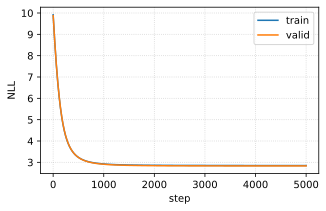

In [37]:
#| code-fold: true
plt.figure(figsize=(5, 3))
plt.plot(history_gen_imdb["train"], label="train")
plt.plot(history_gen_imdb["valid_steps"], history_gen_imdb["valid"], label="valid")
plt.legend()
plt.xlabel("step")
plt.ylabel("NLL")
plt.grid(linestyle="dotted", alpha=0.6);

**Noise-aware training.** We train an MLP on TF-IDF features using the noise-aware loss, weighted by the generative model's soft labels. The discriminative model can generalize beyond the keywords used in the LFs by leveraging the full TF-IDF vocabulary:

In [38]:
np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

clf_imdb = nn.Sequential(nn.Linear(5000, 32), nn.SELU(), nn.Linear(32, K))
trainer_imdb = NoiseAwareTrainer(clf_imdb, gen_model_imdb)
history_nat_imdb = trainer_imdb.run(
    x_train_imdb, x_valid_imdb, L_train_imdb, L_valid_imdb,
    epochs=300, bs=64, lr=0.003, alpha=0.0, momentum=0.9,
)

 52%|█████▏    | 156/300 [00:09<00:08, 16.36it/s]

Early stopping at epoch 156...
Training stopped.
Best valid loss: 0.5080917477607727


Training and validation loss for the noise-aware discriminative model:

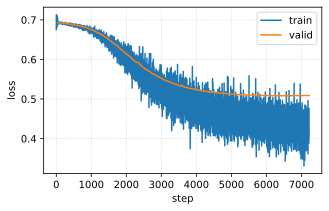

In [39]:
#| code-fold: true
plt.figure(figsize=(5, 3))
plt.plot(history_nat_imdb["train"], label="train")
plt.plot(history_nat_imdb["valid_steps"], history_nat_imdb["valid"], label="valid")
plt.legend()
plt.xlabel("step")
plt.ylabel("loss")
plt.grid(linestyle="dotted", alpha=0.6);

**Evaluation.** We compare the generative model (LF outputs only) with the noise-aware discriminative model (TF-IDF features), and apply the same prior-based threshold calibration from the synthetic experiments:

In [40]:
print("GenModel (IMDB):")
print(evaluate(gen_model_imdb, L_train_imdb, y_train_imdb, t=0.5)["message"]); print()
print(evaluate(gen_model_imdb, L_valid_imdb, y_valid_imdb, t=0.5)["message"])

print("\nNoiseAwareTrainer (IMDB):")
print(evaluate(trainer_imdb, x_train_imdb, y_train_imdb, t=0.5)["message"]); print()
print(evaluate(trainer_imdb, x_valid_imdb, y_valid_imdb, t=0.5)["message"])

# Threshold calibration using label prior
calibration_score = []
thresholds = np.linspace(0, 1, num=500)
for t in thresholds:
    c = Counter(trainer_imdb.predict(x_train_imdb, t).tolist())
    n = len(x_train_imdb)
    c[0] = c.get(0, 1) / n
    c[1] = c.get(1, 1) / n
    calibration_score.append(-IMDB_LABEL_PROBS[0] * np.log(c[0]) + -IMDB_LABEL_PROBS[1] * np.log(c[1]))

t_best_imdb = thresholds[np.argmin(calibration_score)]
print(f"\nCalibrated NoiseAwareTrainer (IMDB, t={t_best_imdb:.4f}):")
print(evaluate(trainer_imdb, x_train_imdb, y_train_imdb, t=t_best_imdb)["message"]); print()
print(evaluate(trainer_imdb, x_valid_imdb, y_valid_imdb, t=t_best_imdb)["message"])

GenModel (IMDB):
[[1194  314]
 [ 365 1127]]
m=3000, f1=0.77358, t=0.50000

[[406 101]
 [129 364]]
m=1000, f1=0.76973, t=0.50000

NoiseAwareTrainer (IMDB):
[[1157  351]
 [ 234 1258]]
m=3000, f1=0.80474, t=0.50000

[[409  98]
 [ 83 410]]
m=1000, f1=0.81900, t=0.50000

Calibrated NoiseAwareTrainer (IMDB, t=0.5491):
[[1202  306]
 [ 298 1194]]
m=3000, f1=0.79867, t=0.54910

[[433  74]
 [121 372]]
m=1000, f1=0.80444, t=0.54910


The noise-aware model outperforms the generative model on IMDB reviews. While the generative model can only make predictions based on at most $3^7 = 2187$ LF output patterns, the discriminative model leverages [5000 TF-IDF features]{.mark} to capture sentiment signals beyond the keywords hardcoded in our LFs. Threshold calibration provides a small additional lift by aligning the predicted label distribution with the assumed prior (`LABEL_PROBS`). This demonstrates the core value of the **data programming pipeline**: noisy LFs provide initial supervision, and the discriminative model generalizes from there.

$\blacksquare$

---